$$\xi_1 \sim \mathcal{N}(a_1, \varphi_1^2), \quad \eta_1 \sim \mathcal{N}(b_1, \psi_1^2)$$
$$\xi_2 \sim \mathcal{N}(a_2, \varphi_2^2), \quad \eta_2 \sim \mathcal{N}(b_2, \psi_2^2)$$

$$H_0: \varphi_1^2 = \psi_1^2, \quad \varphi_2^2 = \psi_2^2$$

$$H_1: \varphi_1^2 \neq \psi_1^2 \quad \text{или} \quad \varphi_2^2 \neq \psi_2^2$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

l_sigma1, l_sigma2 = 5.722, 6.161
w_sigma1, w_sigma2 = 4.612, 5.055

egypt_skulls = 139
europe_skulls  = 1000

n1 = egypt_skulls - 1
n2 = europe_skulls - 1

F_length = (l_sigma1 ** 2) / (l_sigma2 ** 2)
F_width  = (w_sigma1 ** 2) / (w_sigma2 ** 2)

alpha = 0.05
quantile_2_5   = f.ppf(alpha / 2, n1, n2)
quantile_97_5  = f.ppf(1 - alpha / 2, n1, n2)

print(f"F (длина):  {F_length:.3f}")
print(f"F (ширина): {F_width:.3f}")
print(f"Критическая область: [{quantile_2_5:.3f}, {quantile_97_5:.3f}]")

F (длина):  0.863
F (ширина): 0.832
Критическая область: [0.767, 1.272]


In [ ]:
p_value_length = f.sf(F_length, n1, n2)
p_value_width  = f.sf(F_width, n1, n2)

print(f"p_value (длина)  = {p_value_length:.5f}")
print(f"p_value (ширина) = {p_value_width:.5f}")

p_value (длина)  = 0.86359
p_value (ширина) = 0.91342


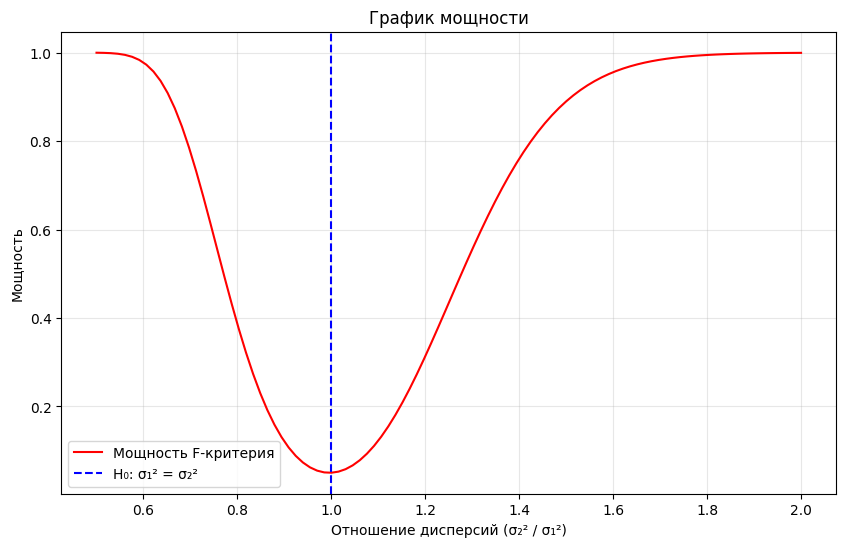

In [5]:
# Функция мощности критерия
lambda_vals = np.linspace(0.5, 2.0, 100)   # отношение дисперсий (σ₂² / σ₁²)
power = (1 - f.cdf(quantile_97_5, n1, n2, scale=lambda_vals) +
              f.cdf(quantile_2_5, n1, n2, scale=lambda_vals))

plt.figure(figsize=(10, 6))
plt.plot(lambda_vals, power, color="red", label="Мощность F-критерия")
plt.axvline(x=1.0, color="blue", linestyle="--", label="H₀: σ₁² = σ₂²")
plt.xlabel("Отношение дисперсий (σ₂² / σ₁²)")
plt.ylabel("Мощность")
plt.title("График мощности")
plt.legend()
plt.grid(alpha=0.3)
plt.show()